# Introduction

For this short project, an analysis is done on a campus recruitment dataset found at https://www.kaggle.com/datasets/benroshan/factors-affecting-campus-placement.

The dataset tells us wheter a university graduate most probably in India, gets job placement after university along with other factors which maybe be involved in the outcome.

The dataset has 15 columns and over 200 entries.

---



In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from wordcloud import WordCloud,STOPWORDS
import plotly.express as px

In [ ]:
data = pd.read_csv('Placement_Data_Full_Class.csv')

In [ ]:
data.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


We can see that the academic qualifications of the people are included in the dataset. The ssc_p is referreing to the Secondary School Certificate percantage which is the 10th grade marks of High School. This is quivalent to Malaysian SPM. SImilarly the hsc_p is referreing to the Higher Secondary Certificate or school class 12 marks which is equivalent to Malaysian STPM.

The dataset also includes thier degree choices, work experience, mba percenatage and other factors that maybe utilised by a company to give placements.


In [ ]:
data.info()

In [ ]:
data.describe()

In [ ]:
data.isna().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

So there are some null values in the salary column. These could be the ones that did not get any placement. Instead of NA we put 0 as the salary they have.

In [ ]:
data['salary'].fillna(0,inplace = True)

In [ ]:
data.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


# Descriptive Analysis

---



# Which gender got more placement?

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


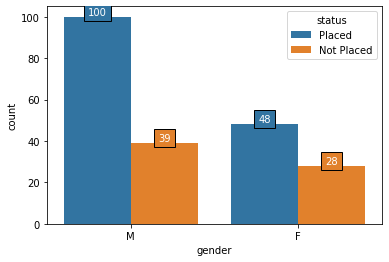

In [ ]:
ax = sns.countplot("gender", hue="status", data=data)
for patch in ax.patches:
    x0, y0 = patch.get_xy()   # Bottom-left corner.
    x0 += patch.get_width()/2 # Middle of the width.
    y0 += patch.get_height()  # Top of the bar
    color = patch.get_facecolor()
    ax.text(x0, y0, str(y0), ha="center", va="bottom", color="white", clip_on=True, bbox=dict(ec="black",fc=color))


We can see that more males are getting placement than the females. Out of 139, 39 males didint get placed whereas out of just 76 females, 28 didnt get placements.

# Which degree graduates recieves a better salary?

Text(0, 0.5, 'Salary')

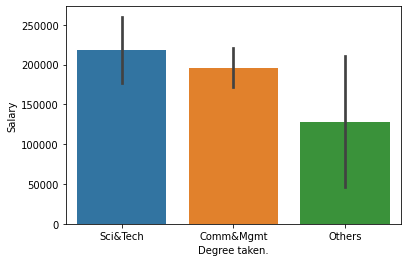

In [ ]:
y = sns.barplot(x = data["degree_t"] , y = data["salary"])
plt.xlabel("Degree taken.")
plt.ylabel("Salary")


We can see that the degrees related to Science & Technology receives the highest ranage of salaries with Commerce & Management fields a close second. However, degrees in other fields recieves comparitively less salaries.

# Exploratory Analysis

---



# Are marks or percentages important in getting placement?

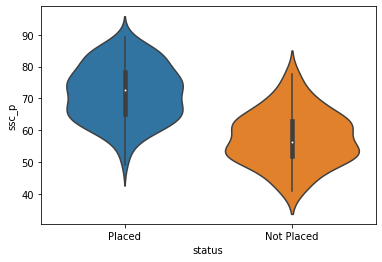

In [ ]:
sns.violinplot(x="status", y="ssc_p", data=data)


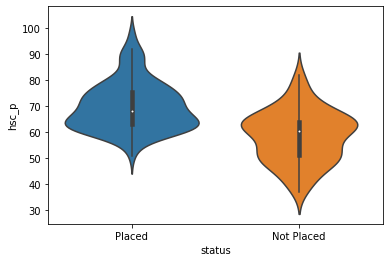

In [ ]:
sns.violinplot(x="status", y="hsc_p", data=data)

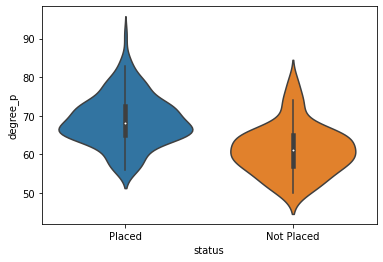

In [ ]:
sns.violinplot(x="status", y="degree_p", data=data)


*   From the 3 violin plots, it is clear that percentage of marks acquired througout their student life has a correlation with getting placments.
*   Those not getting placaments are in the region of 50-70 where as those that do get placed are more around 70 percantage.


*   The biggest diffrence is in the SSC percentage where the placed graduates had median percentage above 70 percent and those not placed had median percentage below 60 percent.






# Does higher percentage in degree and mba results in higher salary?



In [ ]:
figure = px.scatter(data, x='degree_p', y='salary')
figure.update_layout(title='Degree Percentage vs Salary', xaxis_title="Degree Percentage ", yaxis_title="Salary")
figure.show()

In [ ]:
figure2 = px.scatter(data, x='mba_p', y='salary')
figure2.update_layout(title='MBA Percentage vs Salary', xaxis_title="MBA Percentage ", yaxis_title="Salary")
figure2.show()

There are some diffrences that can be seen between the 2 percentages and the effect they have on salary.

*   The MBA percentages do not go above 80 meaning it is much harder to score than in degree.
*   Majority of the graduates have a slary range between 0.2M and 0.4M irrespective to their percentage.
*   In degree those that got below 55 percentage did not get any placement where as many below 55 percentage in MBA got placements.
*   The chances of not getting pacement after scoring 70 percent and above are very low.


Therfore we can say that you cannot get less than 55 percent in degree results to have a chance in getting placements. Other than that higher marks does not mean higher salary, but does mean that there is less chance to not get placements.






# Inferential Analysis

# Is studying under the country Central Board in India important for getting placements?

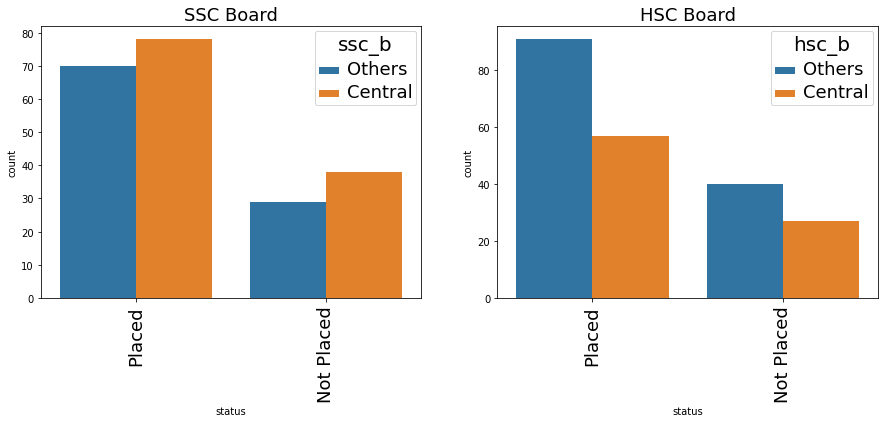

In [ ]:
f,ax=plt.subplots(1,2,figsize=(15,5)) # Double plots

sns.countplot(x='status', hue="ssc_b", data=data, ax=ax[0])
sns.countplot(x='status', hue='hsc_b', data=data, ax=ax[1])
ax[0].set_title('SSC Board', fontsize=18)
ax[1].set_title('HSC Board', fontsize=18)
ax[0].tick_params(axis='x', labelsize=18,rotation = 90)
ax[1].tick_params(axis='x', labelsize=18, rotation=90)
plt.setp(ax[0].get_legend().get_texts(), fontsize='18')
plt.setp(ax[0].get_legend().get_title(), fontsize='20')
plt.setp(ax[1].get_legend().get_texts(), fontsize='18')
plt.setp(ax[1].get_legend().get_title(), fontsize='20')
plt.show()

We can see that many choose to leave the central board after their SSC(class 10) exams and continue studying under other boards for their HSC(Class 12). This could mean that they feel central board isn't equipped to handle higher secondary education. However, there is no notable differences found inspite of the change. This means that the board chosen does not play a significant impact on the placements received.

# Predictive analysis

---



In [ ]:
data.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          215 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


# How accurately can we predict wether or not a graduate will get placement or not depending on data?

Pre-Processing


The dataset had null values but only in the salary column. However, we
will not be using the salary column as having salary already means that they have gotten placements.
Also, we have seen that the board of choice does not really matter when it comes to placements therfore we will drop those columns.

*  The dataset had null values but only in the salary column. However, we will not be using the salary column as having salary already means that they have gotten placements.
*  Also, in the inferential analysis, we have seen that the board of choice does not really matter when it comes to placements therfore we will drop those columns.
*   Also dropping the serial number column as it does not matter.


We will need to encode the categorical variables namely the gender, hsc_s, degree_t, workex, specialization and status.

In [ ]:
#creating a copy dataframe to do predictions
df = data.copy()

In [ ]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,0,67.00,Others,91.00,Others,0,58.00,0,1,55.0,0,58.80,0,270000.0
1,2,0,79.33,Central,78.33,Others,1,77.48,0,0,86.5,1,66.28,0,200000.0
2,3,0,65.00,Central,68.00,Central,2,64.00,1,1,75.0,1,57.80,0,250000.0
3,4,0,56.00,Central,52.00,Central,1,52.00,0,1,66.0,0,59.43,1,0.0
4,5,0,85.80,Central,73.60,Central,0,73.30,1,1,96.8,1,55.50,0,425000.0


In [ ]:
#Encoding variables

df["gender"] = df.gender.map({"M":0,"F":1})
df["hsc_s"] = df.hsc_s.map({"Commerce":0,"Science":1, "Arts":2})
df["degree_t"] = df.degree_t.map({"Sci&Tech":0,"Comm&Mgmt":1, "Others":2})
df["workex"] = df.workex.map({"Yes":0,"No":1})
df["specialisation"] = df.specialisation.map({"Mkt&HR":0,"Mkt&Fin":1})
df["status"] = df.status.map({"Placed":0,"Not Placed":1})

In [ ]:
df.drop(['sl_no','ssc_b','hsc_b','salary'], axis=1, inplace=True)# Droppin unnecassry columns

In [ ]:
df.head()

,gender,ssc_p,hsc_p,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,0,67.00,91.00,0,58.00,0,1,55.0,0,58.80,0
1,0,79.33,78.33,1,77.48,0,0,86.5,1,66.28,0
2,0,65.00,68.00,2,64.00,1,1,75.0,1,57.80,0
3,0,56.00,52.00,1,52.00,0,1,66.0,0,59.43,1
4,0,85.80,73.60,0,73.30,1,1,96.8,1,55.50,0


Splitting data

In [ ]:
X=df.drop(['status'], axis=1)
y=df['status']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train, y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42 )

In [ ]:
#Feature scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Since we are trying to predict whether a person gets placement or not, it is a binary classification problem. Support vector machine model is best for such classification as it divides points based on a hyperplane dividing the 2 classes.

In [ ]:
from sklearn.svm import SVC
svm = SVC(kernel= 'linear', random_state=1, C=0.1)
svm.fit(X_train, y_train)

SVC(C=0.1, kernel='linear', random_state=1)

In [ ]:
predictions = svm.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

[[29  2]
 [ 3  9]]
              precision    recall  f1-score   support

           0       0.91      0.94      0.92        31
           1       0.82      0.75      0.78        12

    accuracy                           0.88        43
   macro avg       0.86      0.84      0.85        43
weighted avg       0.88      0.88      0.88        43



Therefore, we can say that we can predict wether or not a person will get placements with 88 percent accuracy.



# References



*  Patel (2020), Campus Recruitment analysis
https://www.kaggle.com/code/yashvi/campus-recruitment-analysis#-7.-MBA-percentage-distribution-by-specialisation-
* Joshi(2021), Notebook For Beginners
https://www.kaggle.com/code/aakashjoshi123/notebook-for-beginners#Creating-Independent-Variables-and-Dependent-Variable


*  Kumar (2020), How about getting placements?- A Data Exploration
https://www.kaggle.com/code/granjithkumar/how-about-getting-placements-a-data-exploration
*  Tripathi (2020), EDA + Classification - Achieving 92.3% Accuracy
https://www.kaggle.com/code/nishkarshtripathi/eda-classification-achieving-92-3-accuracy


